# COSMOS vs Detection Catalog— g₁ / g₂ distribution comparison

Compares the reduced shear distributions between the COSMOS-based catalog and the Detected catalog, for both the train and eval splits.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.stats import gaussian_kde

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
})

COLORS = {
    'sim':    '#3B4CC0',   # blue  — detected catalog
    'cosmos': '#B40426',   # red   — COSMOS catalog
}


## 1 · Configuration

In [2]:
import os

TRAIN_SIM    = '/home/adfield/ShearNet/cosmos_catalog_train.fits'
TRAIN_COSMOS = '/home/adfield/ShearNet/cosmos_catalog_train_COSMOS.fits'
EVAL_SIM     = '/home/adfield/ShearNet/cosmos_catalog_eval.fits'
EVAL_COSMOS  = '/home/adfield/ShearNet/cosmos_catalog_eval_COSMOS.fits'

OUT_DIR = '/home/adfield/ShearNet/'
os.makedirs(OUT_DIR, exist_ok=True)


## 2 · Load data

In [3]:
def load(path):
    t = Table.read(path)
    return {
        'g1':  np.asarray(t['G1']),
        'g2':  np.asarray(t['G2']),
        'q':  np.asarray(t['Q']),
        'N':   len(t),
        'name': os.path.basename(path),
    }

train_sim    = load(TRAIN_SIM)
train_cosmos = load(TRAIN_COSMOS)
eval_sim     = load(EVAL_SIM)
eval_cosmos  = load(EVAL_COSMOS)

for d in [train_sim, train_cosmos, eval_sim, eval_cosmos]:
    print(f"{d['name']:50s}  N={d['N']:>8,}  "          f"g1: {d['g1'].mean():.4f} ± {d['g1'].std():.4f}  "          f"g2: {d['g2'].mean():.4f} ± {d['g2'].std():.4f}")


cosmos_catalog_train.fits                           N= 536,976  g1: -0.0002 ± 0.2686  g2: 0.0001 ± 0.2686
cosmos_catalog_train_COSMOS.fits                    N= 307,845  g1: -0.0399 ± 0.2923  g2: 0.0017 ± 0.2721
cosmos_catalog_eval.fits                            N= 357,984  g1: 0.0001 ± 0.2680  g2: 0.0003 ± 0.2684
cosmos_catalog_eval_COSMOS.fits                     N= 205,230  g1: -0.0399 ± 0.2929  g2: 0.0012 ± 0.2721


## 3 · g₁ & g₂ distributions: COSMOS vs Detection

Saved → /home/adfield/ShearNet/g1g2_cosmos_vs_detection.png


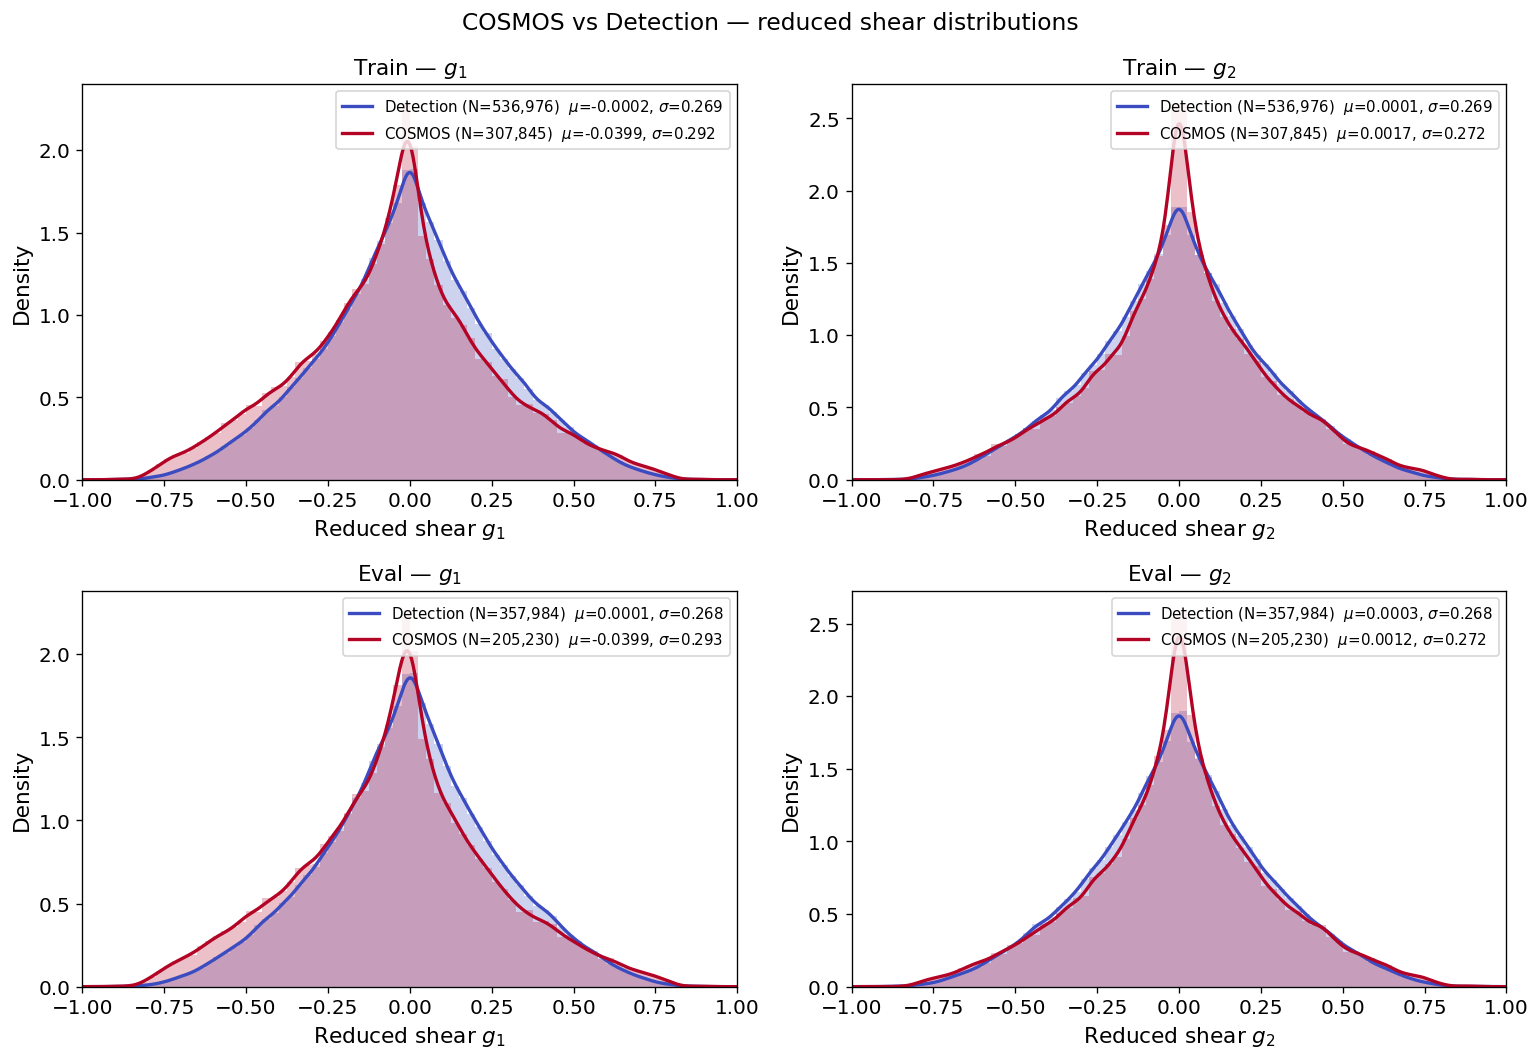

In [4]:
def plot_g_comparison(ax, sim_arr, cosmos_arr, component, split_label,
                      n_sim, n_cosmos, nbins=80):
    """Overlay KDE + histogram for one shear component, one split."""    
    xlim = (-1.0, 1.0)
    x = np.linspace(*xlim, 500)

    for arr, col, label, N in [
        (sim_arr,    COLORS['sim'],    'Detection', n_sim),
        (cosmos_arr, COLORS['cosmos'], 'COSMOS',    n_cosmos),
    ]:
        valid = arr[np.isfinite(arr)]
        ax.hist(valid, bins=nbins, range=xlim, density=True,
                color=col, alpha=0.25, linewidth=0)
        kde = gaussian_kde(valid, bw_method='scott')
        ax.plot(x, kde(x), color=col, lw=2.0,
                label=rf"{label} (N={N:,})  $\mu$={valid.mean():.4f}, $\sigma$={valid.std():.3f}")

    comp_label = r'$g_1$' if component == 'g1' else r'$g_2$'
    ax.set_xlabel(rf'Reduced shear {comp_label}')
    ax.set_ylabel('Density')
    ax.set_title(f'{split_label} — {comp_label}')
    ax.set_xlim(xlim)
    ax.legend(fontsize=9)


fig, axes = plt.subplots(2, 2, figsize=(13, 9))

plot_g_comparison(axes[0, 0], train_sim['g1'], train_cosmos['g1'],
                  'g1', 'Train', train_sim['N'], train_cosmos['N'])
plot_g_comparison(axes[0, 1], train_sim['g2'], train_cosmos['g2'],
                  'g2', 'Train', train_sim['N'], train_cosmos['N'])
plot_g_comparison(axes[1, 0], eval_sim['g1'],  eval_cosmos['g1'],
                  'g1', 'Eval',  eval_sim['N'],  eval_cosmos['N'])
plot_g_comparison(axes[1, 1], eval_sim['g2'],  eval_cosmos['g2'],
                  'g2', 'Eval',  eval_sim['N'],  eval_cosmos['N'])

plt.suptitle('COSMOS vs Detection — reduced shear distributions', fontsize=14)
plt.tight_layout()

out = os.path.join(OUT_DIR, 'g1g2_cosmos_vs_detection.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved → {out}')

Saved → /home/adfield/ShearNet/q_cosmos_vs_detection.png


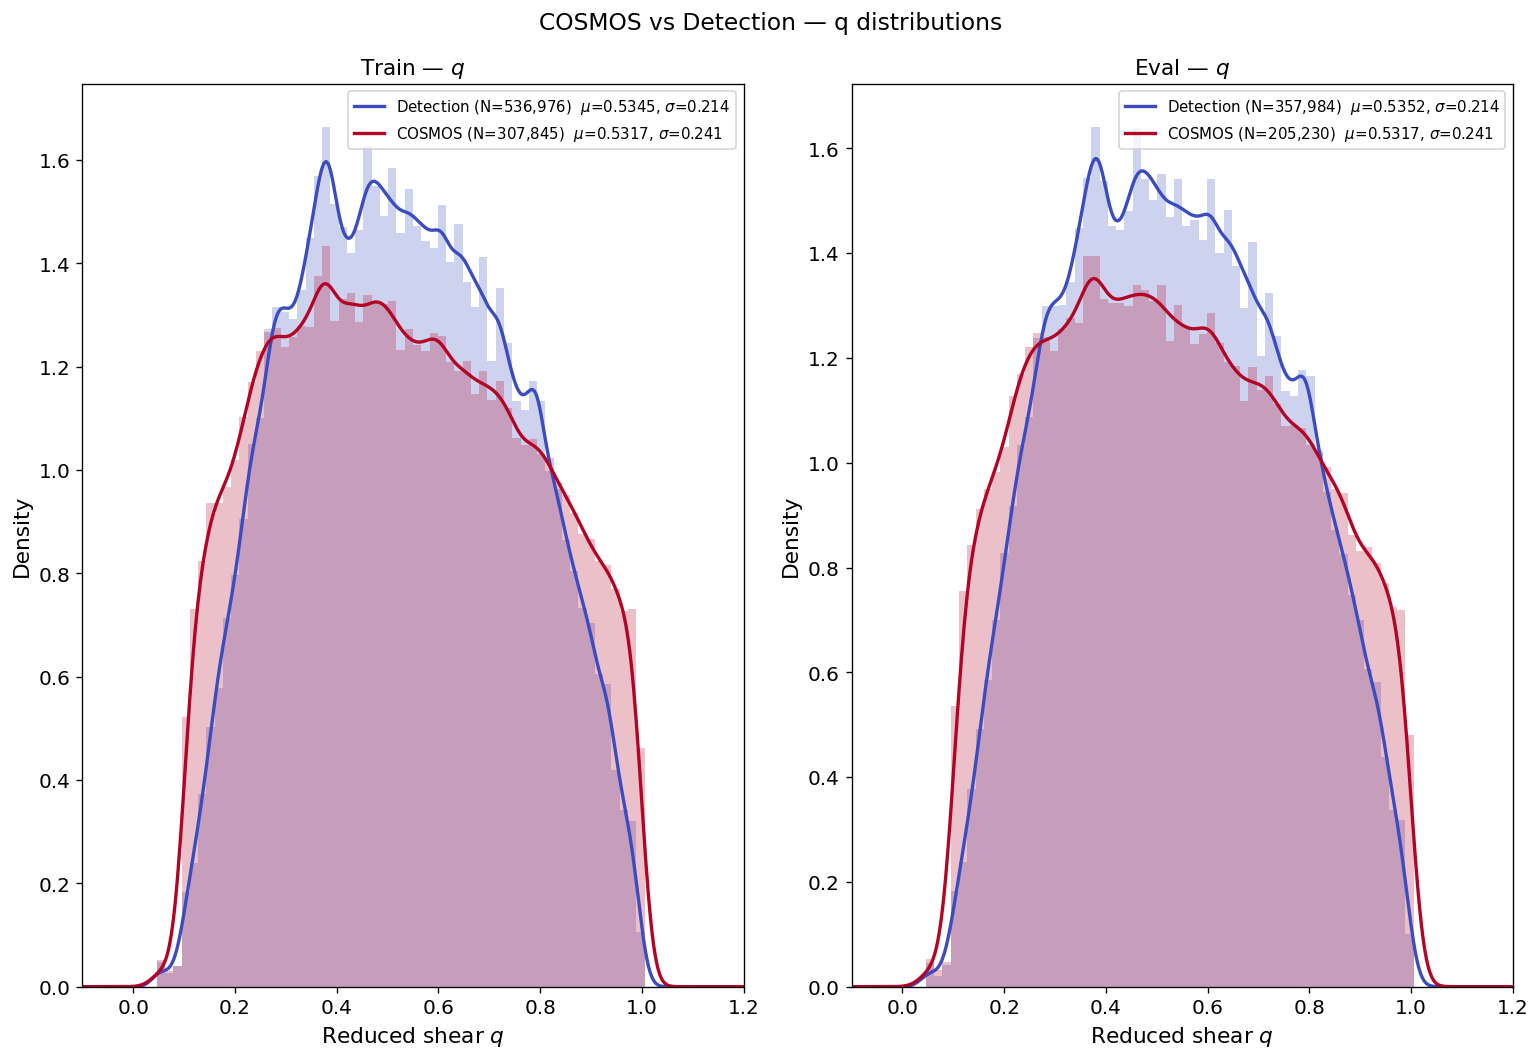

In [12]:
def plot_q_comparison(ax, sim_arr, cosmos_arr, component, split_label,
                      n_sim, n_cosmos, nbins=80):
    """Overlay KDE + histogram for one shear component, one split."""    
    xlim = (-0.1, 1.2)
    x = np.linspace(*xlim, 500)

    for arr, col, label, N in [
        (sim_arr,    COLORS['sim'],    'Detection', n_sim),
        (cosmos_arr, COLORS['cosmos'], 'COSMOS',    n_cosmos),
    ]:
        valid = arr[np.isfinite(arr)]
        ax.hist(valid, bins=nbins, range=xlim, density=True,
                color=col, alpha=0.25, linewidth=0)
        kde = gaussian_kde(valid, bw_method='scott')
        ax.plot(x, kde(x), color=col, lw=2.0,
                label=rf"{label} (N={N:,})  $\mu$={valid.mean():.4f}, $\sigma$={valid.std():.3f}")

    comp_label = r'$q$' if component == 'q' else r'unknown label'
    ax.set_xlabel(rf'Reduced shear {comp_label}')
    ax.set_ylabel('Density')
    ax.set_title(f'{split_label} — {comp_label}')
    ax.set_xlim(xlim)
    ax.legend(fontsize=9)


fig, axes = plt.subplots(1, 2, figsize=(13, 9))


plot_q_comparison(axes[0], train_sim['q'], train_cosmos['q'],
                  'q', 'Train', train_sim['N'], train_cosmos['N'])
plot_q_comparison(axes[1], eval_sim['q'],  eval_cosmos['q'],
                  'q', 'Eval',  eval_sim['N'],  eval_cosmos['N'])

plt.suptitle('COSMOS vs Detection — q distributions', fontsize=14)
plt.tight_layout()

out = os.path.join(OUT_DIR, 'q_cosmos_vs_detection.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved → {out}')

## 4 · Difference plot  (COSMOS − Detected KDE)

Saved → /home/adfield/ShearNet/g1g2_cosmos_vs_detection_diff.png


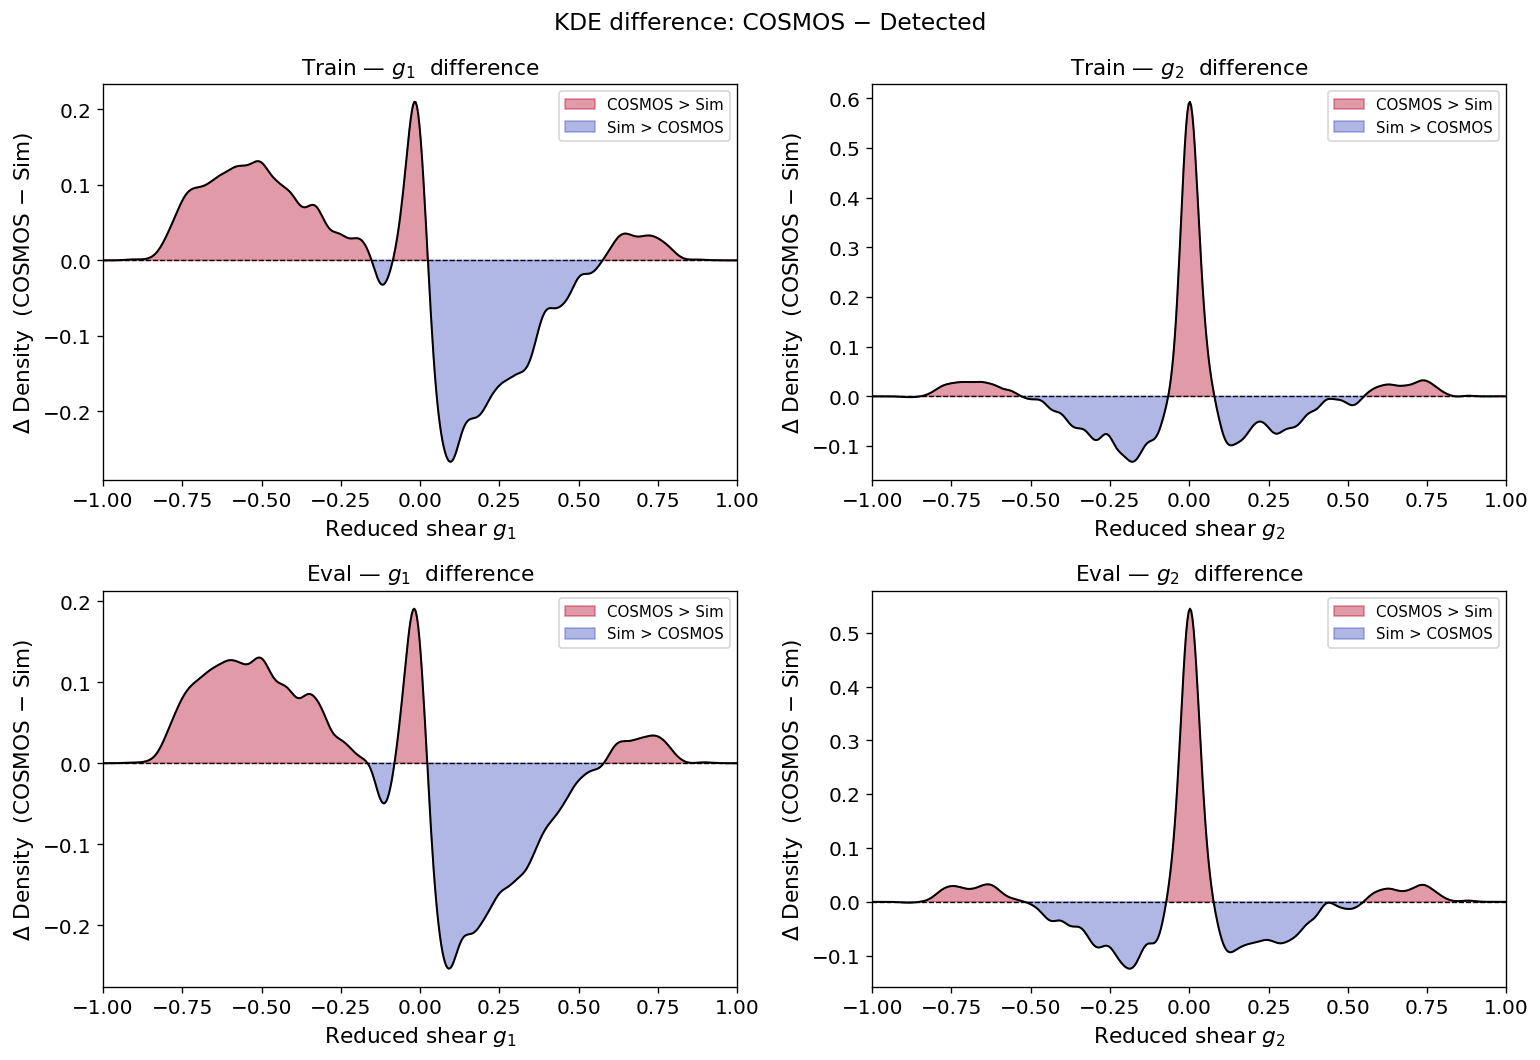

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

x = np.linspace(-1.0, 1.0, 500)

for row, (sim_d, cos_d, split_label) in enumerate([
    (train_sim, train_cosmos, 'Train'),
    (eval_sim,  eval_cosmos,  'Eval'),
]):
    for col, comp in enumerate(['g1', 'g2']):
        ax = axes[row, col]
        sim_v   = sim_d[comp][np.isfinite(sim_d[comp])]
        cos_v   = cos_d[comp][np.isfinite(cos_d[comp])]

        kde_sim = gaussian_kde(sim_v, bw_method='scott')(x)
        kde_cos = gaussian_kde(cos_v, bw_method='scott')(x)
        diff    = kde_cos - kde_sim

        ax.axhline(0, color='k', lw=0.8, ls='--')
        ax.fill_between(x, diff, 0, where=(diff > 0),
                        color=COLORS['cosmos'], alpha=0.4, label='COSMOS > Sim')
        ax.fill_between(x, diff, 0, where=(diff < 0),
                        color=COLORS['sim'],    alpha=0.4, label='Sim > COSMOS')
        ax.plot(x, diff, color='k', lw=1.2)

        comp_label = r'$g_1$' if comp == 'g1' else r'$g_2$'
        ax.set_xlabel(rf'Reduced shear {comp_label}')
        ax.set_ylabel(r'$\Delta$ Density  (COSMOS $-$ Sim)')
        ax.set_title(f'{split_label} — {comp_label}  difference')
        ax.set_xlim(-1.0, 1.0)
        ax.legend(fontsize=9)

plt.suptitle('KDE difference: COSMOS − Detected', fontsize=14)
plt.tight_layout()

out = os.path.join(OUT_DIR, 'g1g2_cosmos_vs_detection_diff.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved → {out}')
